# Datos Faltantes

In [3]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [6]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
238,0.034443,0.050680,-0.009439,0.059744,-0.035968,-0.007577,-0.076536,0.071210,0.011011,-0.021788,257.0
310,-0.005515,-0.044642,0.064930,0.035644,-0.001569,0.014970,-0.013948,0.000729,-0.018114,0.032059,109.0
425,-0.078165,-0.044642,-0.040696,-0.081413,-0.100638,-0.112795,0.022869,-0.076395,-0.020292,-0.050783,152.0
138,0.034443,0.050680,0.111276,0.076958,-0.031840,-0.033881,-0.021311,-0.002592,0.028020,0.073480,336.0
171,-0.020045,-0.044642,-0.046085,-0.098627,-0.075870,-0.059873,-0.017629,-0.039493,-0.051404,-0.046641,74.0
355,-0.074533,0.050680,-0.009439,0.014987,-0.037344,-0.021669,-0.013948,-0.002592,-0.033246,0.011349,60.0
204,0.110727,0.050680,0.006728,0.028758,-0.027712,-0.007264,-0.047082,0.034309,0.002004,0.077622,277.0
122,0.048974,0.050680,0.081097,0.021872,0.043837,0.064134,-0.054446,0.071210,0.032432,0.048628,180.0
83,-0.038207,-0.044642,0.009961,-0.046985,-0.059359,-0.052983,-0.010266,-0.039493,-0.015999,-0.042499,210.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0


In [7]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [8]:
# Cuenta los valores faltantes en cada columna
valores_faltantes = data.isnull().sum()

print(valores_faltantes)

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64


Hay 44 valores faltantes

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [9]:
# Crea el imputador usando la media
imputer = SimpleImputer(strategy='mean')

# Imputa los valores faltantes de la columna bmi
data[['bmi']] = imputer.fit_transform(data[['bmi']])

# Muestra la columna bmi
print(data['bmi'])

0      0.061696
1     -0.051474
2      0.044451
3     -0.011595
4     -0.036385
         ...   
437    0.019662
438   -0.015906
439   -0.015906
440    0.039062
441   -0.073030
Name: bmi, Length: 442, dtype: float64


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [10]:
# Volver a cargar los datos originales
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

# Simular nuevamente valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Imputación simple usando la media
imputer_media = SimpleImputer(strategy='mean')
data_media = data.copy()

data_media[['bmi', 'bp']] = imputer_media.fit_transform(
    data_media[['bmi', 'bp']]
)

# Imputación usando KNN
knn_imputer = KNNImputer(n_neighbors=2)
data_knn = data.copy()

data_knn[['bmi', 'bp']] = knn_imputer.fit_transform(
    data_knn[['bmi', 'bp']]
)

# Comparar algunos resultados
print("Imputación por media:")
print(data_media[['bmi', 'bp']].head(10))

print("\nImputación con KNN:")
print(data_knn[['bmi', 'bp']].head(10))

Imputación por media:
        bmi        bp
0  0.061696  0.021872
1 -0.051474  0.000465
2  0.044451 -0.005670
3 -0.011595 -0.036656
4 -0.036385  0.021872
5 -0.040696 -0.019442
6 -0.047163 -0.015999
7 -0.001895  0.066629
8  0.061696 -0.040099
9 -0.000205 -0.033213

Imputación con KNN:
        bmi        bp
0  0.061696  0.021872
1 -0.051474  0.052858
2  0.044451 -0.005670
3 -0.011595 -0.036656
4 -0.036385  0.021872
5 -0.040696 -0.019442
6 -0.047163 -0.015999
7 -0.001895  0.066629
8  0.061696 -0.040099
9 -0.011595 -0.033213


In [11]:
print("Media de BMI:")
print(data_media['bmi'].mean())

print("\nMedia de BMI con KNN:")
print(data_knn['bmi'].mean())

print("\nMedia de BP:")
print(data_media['bp'].mean())

print("\nMedia de BP con KNN:")
print(data_knn['bp'].mean())

Media de BMI:
-0.00020486982495319117

Media de BMI con KNN:
0.0003909853424058294

Media de BP:
0.0004653782742768812

Media de BP con KNN:
0.000700261319839779


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

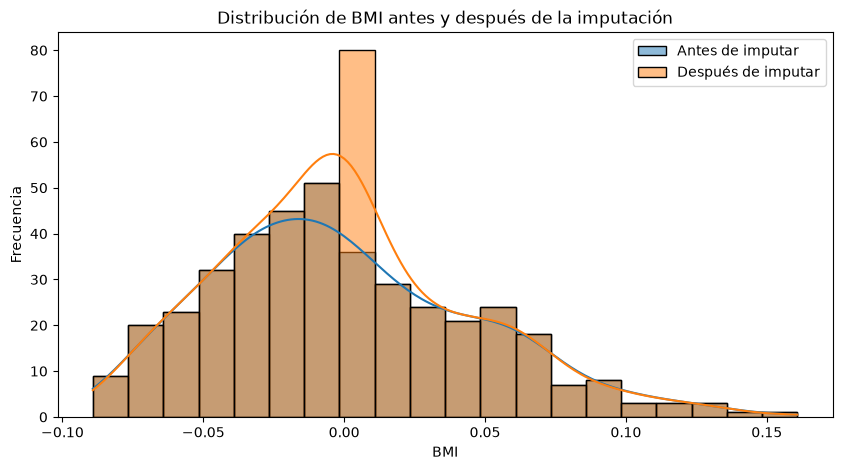

In [12]:
# Guardar los datos de bmi antes de la imputación
bmi_antes = data['bmi'].copy()

# Imputar los valores faltantes con la media
imputer = SimpleImputer(strategy='mean')
data[['bmi']] = imputer.fit_transform(data[['bmi']])

# Crear el histograma
plt.figure(figsize=(10, 5))

sns.histplot(bmi_antes, bins=20, kde=True, label='Antes de imputar')
sns.histplot(data['bmi'], bins=20, kde=True, label='Después de imputar')

plt.title('Distribución de BMI antes y después de la imputación')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()